In [1]:
import cv2
import math
import numpy as np
from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 10]

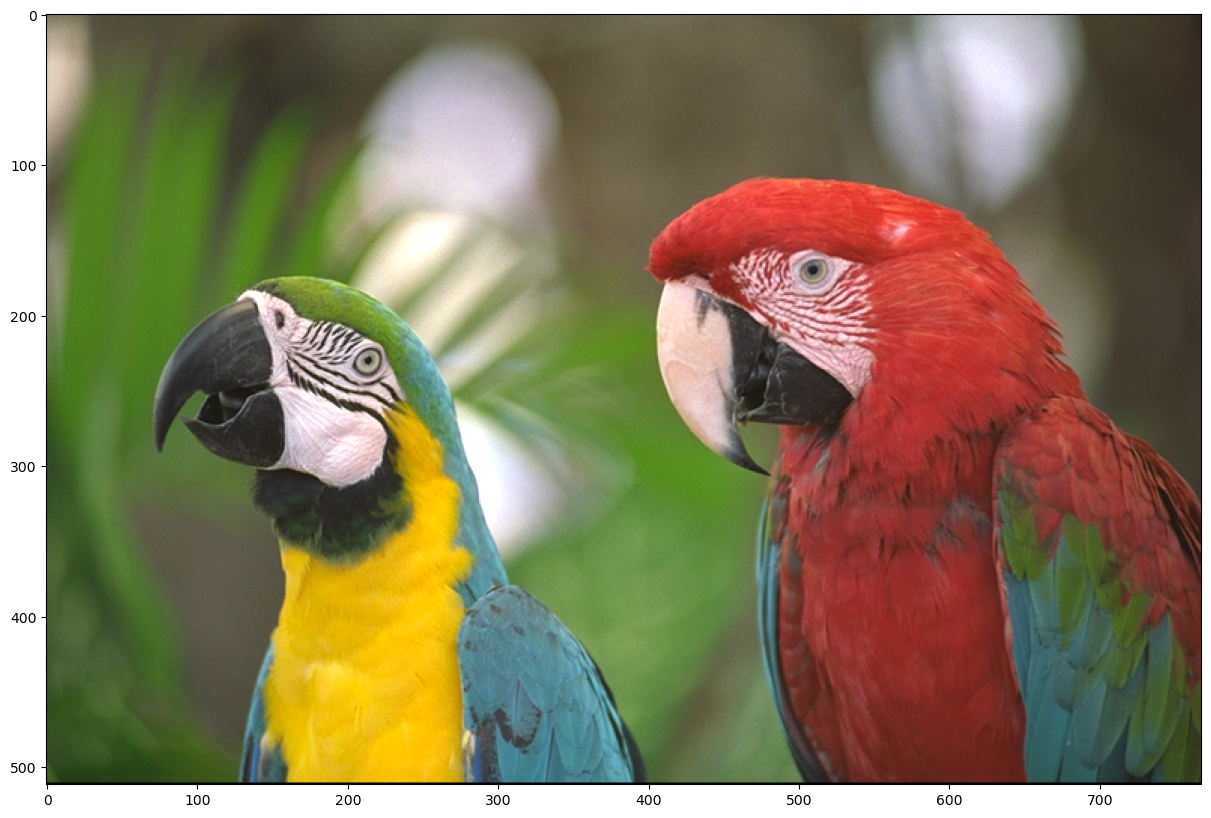

In [3]:
img = cv2.imread('images/kodim23.png')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)

In [4]:
colors = np.array([[0, 0, 0],
                   [64, 64, 64],
                   [192, 192, 192],
                   [255, 255, 255]])

100%|██████████| 512/512 [00:08<00:00, 63.73it/s]


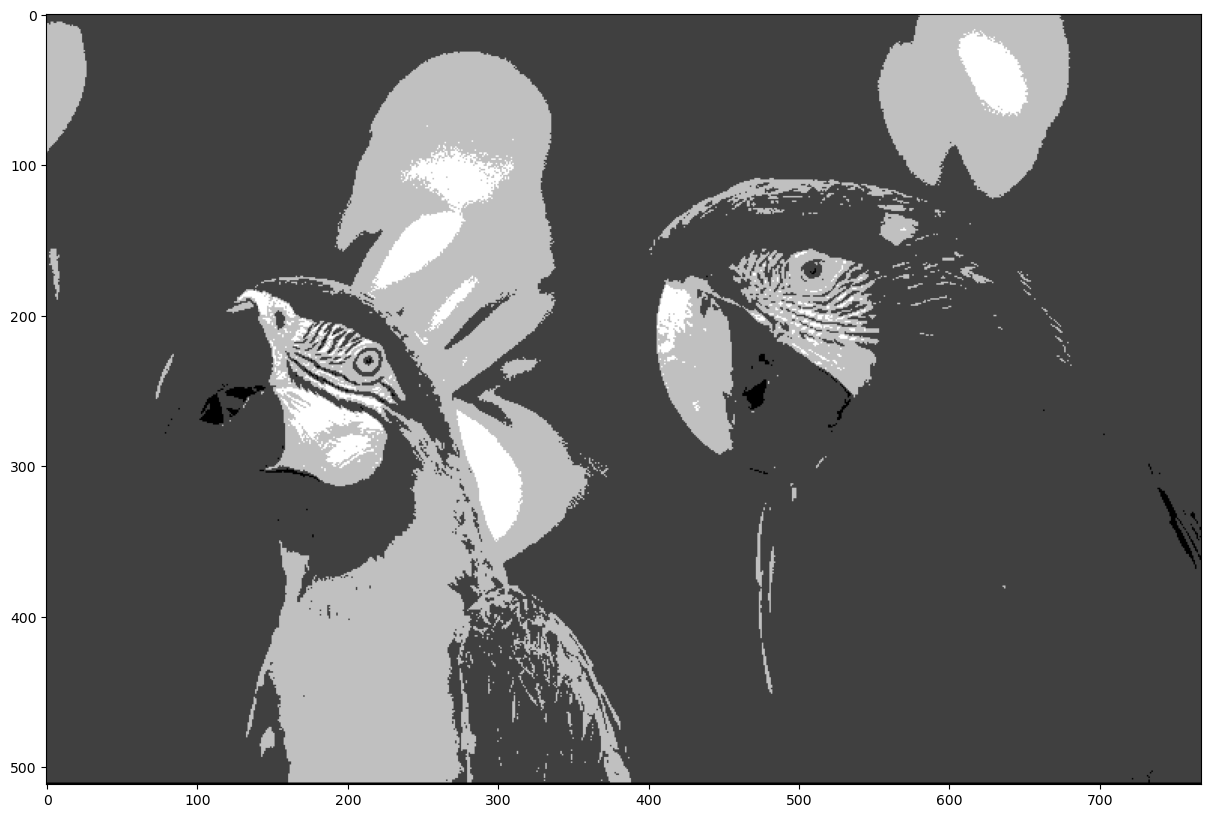

In [15]:
from tqdm import tqdm
img =img.astype(np.float32)
rows, cols, channels = img.shape
quantized = np.zeros_like(img)
for r in tqdm(range(rows)):
    for c in range(cols):
        pixel=img[r, c, :]  
        d = np.linalg.norm(colors - pixel, axis=1) 
        new_pixel = colors[np.argmin(d)]
        quantized[r, c, :] = new_pixel
plt.imshow(quantized.astype(np.uint8))
avg_quant_error = np.sqrt(np.mean((img - quantized) ** 2))


100%|██████████| 510/510 [00:19<00:00, 26.02it/s]


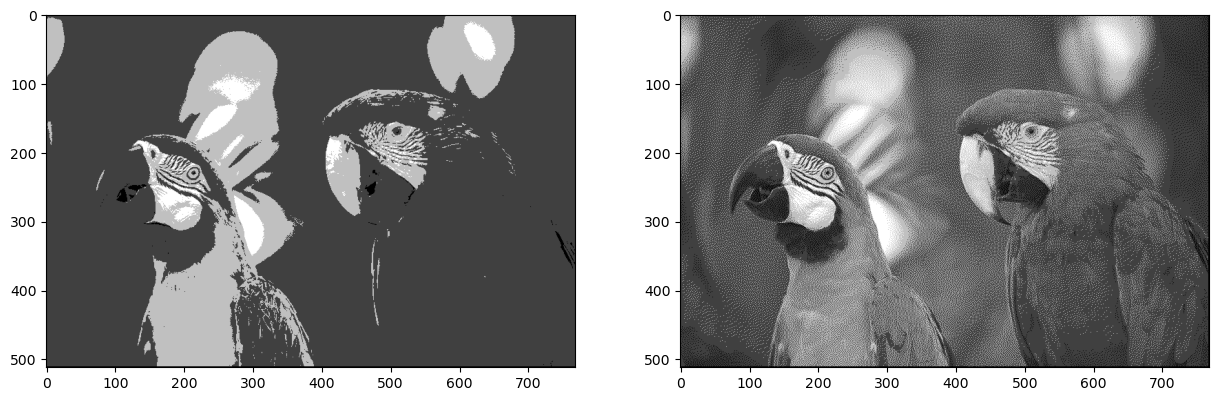

In [16]:
img_tmp = np.copy(img)
dithering = np.zeros_like(img)
for r in tqdm(range(1, rows-1)):
    for c in range(1, cols-1):
        pixel = img_tmp[r, c, :]                      
        d = np.linalg.norm(colors - pixel, axis=1)
        new_pixel = colors[np.argmin(d)]
        quant_error = pixel - new_pixel
        img_tmp[r,   c+1, :] += (7/16) * quant_error
        img_tmp[r+1, c-1, :] += (3/16) * quant_error
        img_tmp[r+1, c,   :] += (5/16) * quant_error
        img_tmp[r+1, c+1, :] += (1/16) * quant_error
        dithering[r, c, :] = new_pixel
plt.subplot(121), plt.imshow(quantized.astype(np.uint8))
plt.subplot(122), plt.imshow(dithering.astype(np.uint8))
avg_dith_error = np.sqrt(np.mean((img - dithering) ** 2))

In [17]:
#1.Which image has higher quantization error? Optimally quantized or dithered?
#- Higher almost always has a dithered image
#- Optimally quantized minimizes the error for each pixel separately, so the average is smaller.
#- A dithered image looks better to the eye, but the average error increases.
#2.Which image looks better to you?
#- The second picture looks better)

In [34]:
colors = np.array([
    [0, 0, 0],
    [255, 255, 255]
], dtype=np.float32)

In [35]:
img_f = img.astype(np.float32)
rows, cols, channels = img_f.shape
quantized = np.zeros_like(img_f)

for r in range(rows):
    for c in range(cols):
        pixel = img_f[r, c, :]                       
        d = np.linalg.norm(colors - pixel, axis=1)   
        new_pixel = colors[np.argmin(d)]             
        quantized[r, c, :] = new_pixel

In [36]:
avg_quant_error = np.sqrt(np.mean((img_f - quantized) ** 2))
img_tmp = np.copy(img_f)
dithering = np.zeros_like(img_f)

for r in range(1, rows-1):
    for c in range(1, cols-1):

        pixel = img_tmp[r, c, :]                     
        d = np.linalg.norm(colors - pixel, axis=1)
        new_pixel = colors[np.argmin(d)]
        dithering[r, c, :] = new_pixel
        quant_error = pixel - new_pixel              
        img_tmp[r,   c+1, :] += (7/16) * quant_error
        img_tmp[r+1, c-1, :] += (3/16) * quant_error
        img_tmp[r+1, c,   :] += (5/16) * quant_error
        img_tmp[r+1, c+1, :] += (1/16) * quant_error

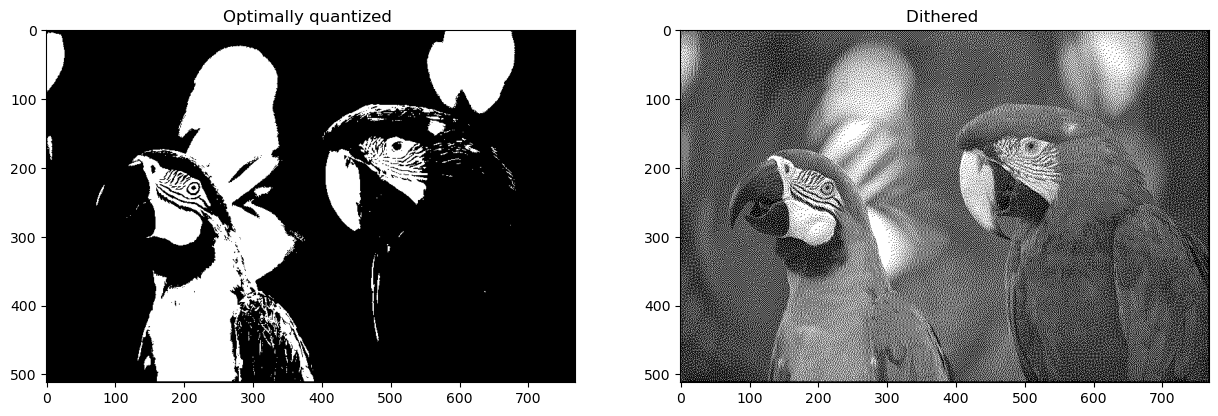

In [37]:
quantized_u8 = np.clip(quantized, 0, 255).astype(np.uint8)
dithering_u8 = np.clip(dithering, 0, 255).astype(np.uint8)

plt.subplot(121); plt.imshow(quantized_u8); plt.title("Optimally quantized ")
plt.subplot(122); plt.imshow(dithering_u8); plt.title("Dithered ")
plt.show()

In [39]:
from sklearn.cluster import KMeans
pixels = img_f.reshape(-1, 3)
kmeans = KMeans(n_clusters=16).fit(np.reshape(img, (-1, 3)))
colors = kmeans.cluster_centers_

In [44]:
quantized = np.zeros_like(img)
for r in tqdm(range(rows)):
    for c in range(cols):
        pixel = img[r, c, :]
        d = np.linalg.norm(colors - pixel, axis=1)
        new_pixel = colors[np.argmin(d)]
        quantized[r, c, :] = new_pixel

avg_quant_error = np.sqrt(np.mean((img - quantized) ** 2))

100%|██████████| 512/512 [00:07<00:00, 64.40it/s]


100%|██████████| 510/510 [00:15<00:00, 33.22it/s]


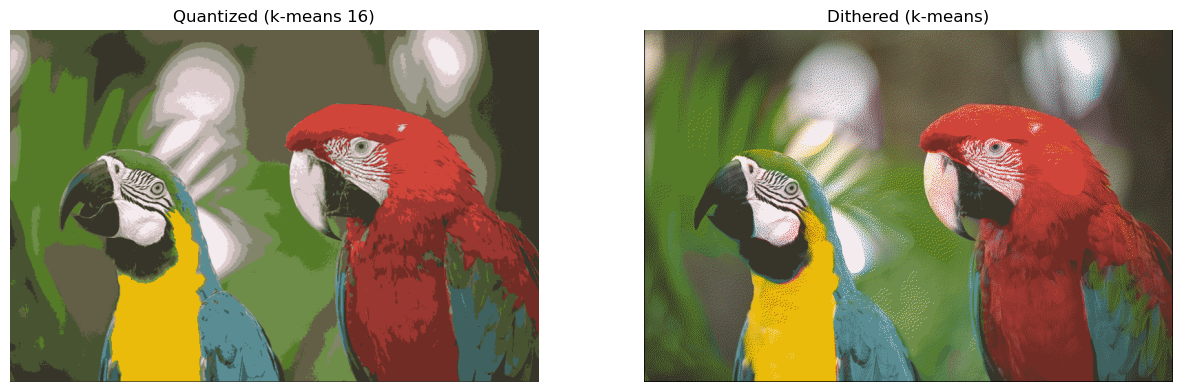

In [45]:
img_tmp = np.copy(img)
dithering = np.zeros_like(img)
for r in tqdm(range(1, rows-1)):
    for c in range(1, cols-1):
        pixel = img_tmp[r, c, :]
        d = np.linalg.norm(colors - pixel, axis=1)
        new_pixel = colors[np.argmin(d)]

        dithering[r, c, :] = new_pixel
        quant_error = pixel - new_pixel

        img_tmp[r,   c+1, :] += (7/16) * quant_error
        img_tmp[r+1, c-1, :] += (3/16) * quant_error
        img_tmp[r+1, c,   :] += (5/16) * quant_error
        img_tmp[r+1, c+1, :] += (1/16) * quant_error

img_tmp[:] = np.clip(img_tmp, 0, 255)

avg_dith_error = np.sqrt(np.mean((img - dithering) ** 2))
plt.subplot(121); plt.imshow(quantized.astype(np.uint8)); plt.title("Quantized (k-means 16)"); plt.axis("off")
plt.subplot(122); plt.imshow(dithering.astype(np.uint8)); plt.title("Dithered (k-means)"); plt.axis("off")
plt.show()

In [ ]:
#1.How does the result look like to you?
# -Dithered looks better, but noise appears on flat areas, and the first image shows steps on gradients.
#2.What happens if we use 32 colours?
#- Quantization will be less aggressive, which is preferable. 
#3.And what happens if we use 256 colours?
#- the result will be very close to the original.